# Chaos Agent (HuggingFace-driven)

This notebook defines a configurable Chaos Agent for property graphs, with optional HuggingFace model guidance.
It operates on `networkx.MultiDiGraph` and injects realistic, systematic corruptions.

What it does
- Builds corruption plans from a small catalog (schema drift, ID collision, entity merge/split, neighbor rewiring).
- Can use a HuggingFace text-generation model to choose which corruption ops to apply.
- Falls back to randomized planning if no model is provided or the model is unavailable.

Dependencies (install as needed)
- `networkx`
- `transformers` (optional, for LLM-guided corruption planning)

In [7]:
import random
import json
from dataclasses import dataclass
from typing import Any, Dict, List, Optional
import matplotlib.pyplot as plt

import networkx as nx

try:
    from transformers import pipeline
except Exception:
    pipeline = None


In [2]:
@dataclass
class CorruptionOp:
    kind: str
    params: Dict[str, Any]


def graph_summary(g: nx.MultiDiGraph) -> str:
    labels: Dict[str, int] = {}

    for _, data in g.nodes(data=True):
        label = data.get("label", "Unknown")
        labels[label] = labels.get(label, 0) + 1
        
    label_items = sorted(labels.items(), key=lambda x: (-x[1], x[0]))
    label_str =  ",".join([f"{k}:{v}" for k, v in label_items])

    return f"nodes={g.number_of_nodes()}, edges={g.number_of_edges()}, labels=[{label_str}]"


def schema_drift(g: nx.MultiDiGraph, from_label: str, to_label: str, p: float = 1.0) -> int:
    changed = 0
    for _, data in g.nodes(data=True):
        if data.get("label") == from_label and random.random() <= p:
            data["label"] = to_label
            changed += 1
    return changed


def pipeline_id_collision(g: nx.MultiDiGraph, id_attr: str = "id") -> int:
    by_id: Dict[Any, List[Any]] = {}
    for n, data in g.nodes(data=True):
        if id_attr in data:
            by_id.setdefault(data[id_attr], []).append(n)
    collisions = [nodes for nodes in by_id.values() if len(nodes) > 1]
    if not collisions:
        return 0
    group = random.choice(collisions)
    keep = group[0]
    for other in group[1:]:
        _merge_nodes(g, keep, other)
    return len(group) - 1


def entity_merge(g: nx.MultiDiGraph, node_a: Any, node_b: Any) -> int:
    if node_a not in g or node_b not in g or node_a == node_b:
        return 0
    _merge_nodes(g, node_a, node_b)
    return 1


def _merge_nodes(g: nx.MultiDiGraph, keep: Any, drop: Any) -> None:
    keep_data = g.nodes[keep]
    drop_data = g.nodes[drop]
    for k, v in drop_data.items():
        if k not in keep_data:
            keep_data[k] = v
    for u, _, key, data in list(g.in_edges(drop, keys=True, data=True)):
        g.add_edge(u, keep, key=key, **data)
    for _, v, key, data in list(g.out_edges(drop, keys=True, data=True)):
        g.add_edge(keep, v, key=key, **data)
    g.remove_node(drop)


def entity_split(g: nx.MultiDiGraph, node: Any, split_ratio: float = 0.5) -> Optional[Any]:
    if node not in g:
        return None
    new_node = f"{node}_dup"
    if new_node in g:
        return None
    g.add_node(new_node, **g.nodes[node])
    in_edges = list(g.in_edges(node, keys=True, data=True))
    out_edges = list(g.out_edges(node, keys=True, data=True))
    random.shuffle(in_edges)
    random.shuffle(out_edges)
    move_in = in_edges[: int(len(in_edges) * split_ratio)]
    move_out = out_edges[: int(len(out_edges) * split_ratio)]
    for u, v, key, data in move_in:
        g.add_edge(u, new_node, key=key, **data)
        g.remove_edge(u, v, key)
    for u, v, key, data in move_out:
        g.add_edge(new_node, v, key=key, **data)
        g.remove_edge(u, v, key)
    return new_node


def adversarial_neighbor_rewire(g: nx.MultiDiGraph, node: Any, k: int = 2) -> int:
    if node not in g:
        return 0
    out_edges = list(g.out_edges(node, keys=True, data=True))
    if not out_edges:
        return 0
    random.shuffle(out_edges)
    rewired = 0
    candidates = list(g.nodes())
    for u, v, key, data in out_edges[:k]:
        new_v = random.choice(candidates)
        if new_v == v:
            continue
        g.add_edge(u, new_v, key=key, **data)
        g.remove_edge(u, v, key)
        rewired += 1
    return rewired


def constraint_targeted(g: nx.MultiDiGraph, constraint_fn, trials: int = 50) -> Optional[CorruptionOp]:
    best_op = None
    best_score = None
    nodes = list(g.nodes())
    if not nodes:
        return None
    for _ in range(trials):
        node = random.choice(nodes)
        op = CorruptionOp("adversarial_neighbor_rewire", {"node": node, "k": 1})
        g_copy = g.copy()
        adversarial_neighbor_rewire(g_copy, **op.params)
        score = constraint_fn(g_copy)
        if best_score is None or score > best_score:
            best_score = score
            best_op = op
    return best_op


class ChaosAgent:
    def __init__(self, model_name: Optional[str] = None, seed: int = 7) -> None:
        self.rng = random.Random(seed)
        self.model_name = model_name
        self.generator = None
        if model_name and pipeline is not None:
            try:
                self.generator = pipeline("text-generation", model=model_name)
            except Exception:
                self.generator = None

    def plan(self, g: nx.MultiDiGraph, max_ops: int = 3) -> List[CorruptionOp]:
        if self.generator is None:
            return self._random_plan(g, max_ops)
        prompt = (
            "You are a chaos agent for property graphs. Choose up to "
            f"{max_ops} corruption operations from this list: "
            "schema_drift, pipeline_id_collision, entity_merge, entity_split, "
            "adversarial_neighbor_rewire.\n"
            f"Graph summary: {graph_summary(g)}\n"
            "Return a comma-separated list of operation names only."
        )
        try:
            out = self.generator(prompt, max_new_tokens=20, do_sample=True)
            text = out[0]["generated_text"]
        except Exception:
            return self._random_plan(g, max_ops)
        chosen = []
        for name in [
            "schema_drift",
            "pipeline_id_collision",
            "entity_merge",
            "entity_split",
            "adversarial_neighbor_rewire",
        ]:
            if name in text:
                chosen.append(name)
        if not chosen:
            return self._random_plan(g, max_ops)
        return [self._default_op(g, name) for name in chosen[:max_ops]]

    def apply(self, g: nx.MultiDiGraph, ops: List[CorruptionOp]) -> Dict[str, int]:
        results: Dict[str, int] = {}
        for op in ops:
            if op.kind == "schema_drift":
                results[op.kind] = schema_drift(g, **op.params)
            elif op.kind == "pipeline_id_collision":
                results[op.kind] = pipeline_id_collision(g, **op.params)
            elif op.kind == "entity_merge":
                results[op.kind] = entity_merge(g, **op.params)
            elif op.kind == "entity_split":
                new_node = entity_split(g, **op.params)
                results[op.kind] = 1 if new_node else 0
            elif op.kind == "adversarial_neighbor_rewire":
                results[op.kind] = adversarial_neighbor_rewire(g, **op.params)
            else:
                results[op.kind] = 0
        return results

    def _random_plan(self, g: nx.MultiDiGraph, max_ops: int) -> List[CorruptionOp]:
        op_names = [
            "schema_drift",
            "pipeline_id_collision",
            "entity_merge",
            "entity_split",
            "adversarial_neighbor_rewire",
        ]
        self.rng.shuffle(op_names)
        return [self._default_op(g, name) for name in op_names[:max_ops]]

    def _default_op(self, g: nx.MultiDiGraph, name: str) -> CorruptionOp:
        nodes = list(g.nodes())
        labels = list({g.nodes[n].get("label", "Unknown") for n in nodes})
        if name == "schema_drift":
            from_label = labels[0] if labels else "Company"
            to_label = labels[1] if len(labels) > 1 else "Organization"
            return CorruptionOp(name, {"from_label": from_label, "to_label": to_label, "p": 1.0})
        if name == "pipeline_id_collision":
            return CorruptionOp(name, {"id_attr": "id"})
        if name == "entity_merge":
            if len(nodes) < 2:
                return CorruptionOp(name, {"node_a": None, "node_b": None})
            return CorruptionOp(name, {"node_a": nodes[0], "node_b": nodes[1]})
        if name == "entity_split":
            node = nodes[0] if nodes else None
            return CorruptionOp(name, {"node": node, "split_ratio": 0.5})
        if name == "adversarial_neighbor_rewire":
            node = nodes[0] if nodes else None
            return CorruptionOp(name, {"node": node, "k": 2})
        return CorruptionOp(name, {})


In [37]:
def draw_graph(g: nx.MultiDiGraph, title: str, pos=None) -> dict:
    if pos is None:
        pos = nx.spring_layout(g, seed=42)
    else:
        pos = {n: p for n, p in pos.items() if n in g}
        pos = nx.spring_layout(g, pos=pos, fixed=list(pos.keys()), seed=42)

    labels = {n: g.nodes[n].get("label", str(n)) for n in g.nodes()}
    plt.figure(figsize=(6, 4))
    nx.draw_networkx_nodes(g, pos, node_size=700, node_color="#cfe8ff", edgecolors="#1f4f8b")
    nx.draw_networkx_edges(g, pos, arrowstyle="->", arrowsize=12, edge_color="#1f4f8b")
    nx.draw_networkx_labels(g, pos, labels=labels, font_size=9)
    plt.title(title)
    plt.axis("off")
    return pos


def graph_diff_view(g_before: nx.MultiDiGraph, g_after: nx.MultiDiGraph, title: str, pos=None) -> dict:
    if pos is None:
        # Layout on union graph so both views share positions
        g_union = nx.compose(g_before, g_after)
        pos = nx.spring_layout(g_union, seed=42)

    # Node colors: highlight label changes
    node_colors = []
    for n in g_after.nodes():
        if n in g_before.nodes() and g_before.nodes[n].get("label") != g_after.nodes[n].get("label"):
            node_colors.append("#f5a623")  # changed label
        else:
            node_colors.append("#cfe8ff")

    # Edge sets for diff
    def edge_key(u, v, data):
        return (u, v, data.get("relation"))

    before_edges = {edge_key(u, v, d) for u, v, d in g_before.edges(data=True)}
    after_edges = {edge_key(u, v, d) for u, v, d in g_after.edges(data=True)}

    added = after_edges - before_edges
    removed = before_edges - after_edges
    kept = before_edges & after_edges

    def draw_edges(edge_set, color, style="solid"):
        edgelist = [(u, v) for u, v, _ in edge_set]
        nx.draw_networkx_edges(g_after, pos, edgelist=edgelist, edge_color=color, style=style, arrows=True)

    labels = {n: g_after.nodes[n].get("label", str(n)) for n in g_after.nodes()}

    plt.figure(figsize=(7, 5))
    nx.draw_networkx_nodes(g_after, pos, node_size=700, node_color=node_colors, edgecolors="#1f4f8b")
    nx.draw_networkx_labels(g_after, pos, labels=labels, font_size=9)

    draw_edges(kept, "#1f4f8b", "solid")     # unchanged
    draw_edges(added, "#2ca02c", "solid")    # added
    draw_edges(removed, "#d62728", "dashed") # removed

    plt.title(title)
    plt.axis("off")
    return pos

def changed_nodes(g_before, g_after):
    changed = set()
    for n in g_after.nodes():
        if n not in g_before:
            changed.add(n)
        elif g_before.nodes[n].get("label") != g_after.nodes[n].get("label"):
            changed.add(n)
    return changed

def subgraph_around_changes(g_before, g_after, radius=1):
    changed = changed_nodes(g_before, g_after)
    if not changed:
        return g_before.subgraph([]).copy(), g_after.subgraph([]).copy()

    nodes = set()
    for n in changed:
        nodes.add(n)
        nodes.update(nx.ego_graph(g_after, n, radius=radius, undirected=True).nodes())
    return g_before.subgraph(nodes).copy(), g_after.subgraph(nodes).copy()

In [ ]:
def load_dbpedia_graph(path: str) -> nx.MultiDiGraph:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    g = nx.MultiDiGraph()
    for node in data.get("nodes", []):
        g.add_node(node["id"], **{k: v for k, v in node.items() if k != "id"})
    for edge in data.get("edges", []):
        g.add_edge(edge["src"], edge["dst"], relation=edge.get("type"))
    return g

def sample_subgraph(g: nx.MultiDiGraph, k: int = 50) -> nx.MultiDiGraph:
    nodes = list(g.nodes())
    if len(nodes) <= k:
        return g
    seed = random.choice(nodes)
    sub = nx.ego_graph(g, seed, radius=2, undirected=True)
    return g.subgraph(sub.nodes()).copy()
    

In [43]:
from pathlib import Path

OUTPUT_DIR = Path("corrupted_graphs")
OUTPUT_DIR.mkdir(exist_ok=True)
LOG_DIR = OUTPUT_DIR / "logs"
LOG_DIR.mkdir(exist_ok=True)

def save_graph(g: nx.MultiDiGraph, filename: str) -> None:
    data = {
        "nodes": [{"id": n, **g.nodes[n]} for n in g.nodes()],
        "edges": [{"src": u, "dst": v, **d} for u, v, d in g.edges(data=True)],
    }
    
    complete_path = OUTPUT_DIR / filename

    with open(complete_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)

def save_corruption_log(ops, results, filename: str) -> None:
    data = {
        "ops": [{"kind": op.kind, "params": op.params} for op in ops],
        "results": results,
    }

    complete_path = complete_path = LOG_DIR / filename

    with open(complete_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)

[CorruptionOp(kind='adversarial_neighbor_rewire', params={'node': 'c1', 'k': 2}), CorruptionOp(kind='schema_drift', params={'from_label': 'Person', 'to_label': 'Company', 'p': 1.0}), CorruptionOp(kind='entity_split', params={'node': 'c1', 'split_ratio': 0.5})]
{'adversarial_neighbor_rewire': 0, 'schema_drift': 1, 'entity_split': 1}
nodes=4, edges=2, labels=[Company:4]


{'c1': array([-0.03402678,  0.74747083]),
 'c2': array([ 0.6987989, -0.6689883]),
 'p1': array([0.33522788, 0.04068821]),
 'c1_dup': array([-1.        , -0.11917074])}

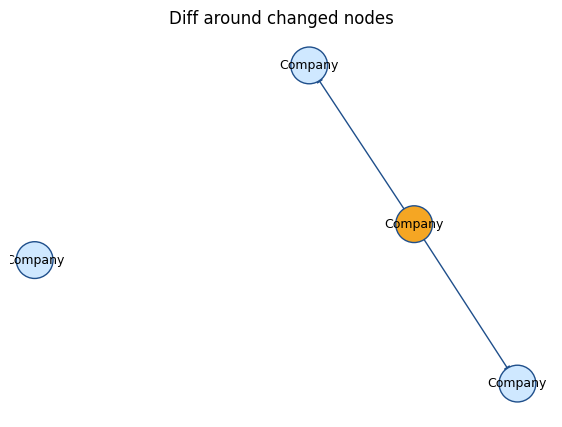

In [38]:
# Example usage
g = nx.MultiDiGraph()
g.add_node("c1", label="Company", id="100")
g.add_node("c2", label="Company", id="100")
g.add_node("p1", label="Person", id="200")
g.add_edge("p1", "c1", relation="WORKS_AT")
g.add_edge("p1", "c2", relation="WORKS_AT")

g_before = g.copy()

agent = ChaosAgent(model_name=None, seed=7)
ops = agent.plan(g, max_ops=3)
results = agent.apply(g, ops)

print(ops)
print(results)
print(graph_summary(g))

sub_before, sub_after = subgraph_around_changes(g_before, g, radius=1)
graph_diff_view(sub_before, sub_after, "Diff around changed nodes")


Before: nodes=2339, edges=3091, labels=[Company:775,Place:636,Location:562,City:291,Country:72,Organisation:3]
Ops: [CorruptionOp(kind='schema_drift', params={'from_label': 'Organisation', 'to_label': 'Country', 'p': 1.0}), CorruptionOp(kind='entity_merge', params={'node_a': '1963', 'node_b': '1964'}), CorruptionOp(kind='entity_split', params={'node': '1963', 'split_ratio': 0.5})]
Results: {'schema_drift': 3, 'entity_merge': 1, 'entity_split': 1}
After: nodes=2339, edges=3091, labels=[Company:776,Place:636,Location:562,City:290,Country:75]


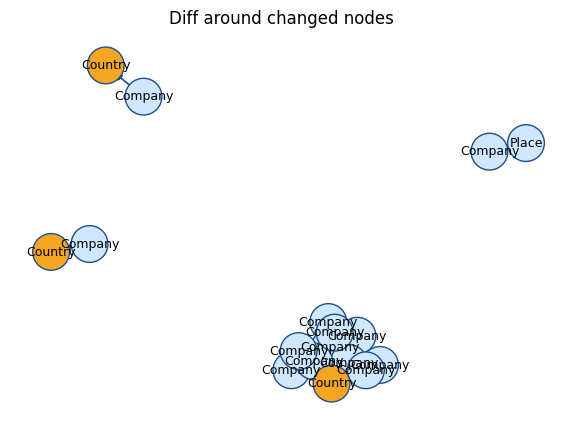

In [46]:
g = load_dbpedia_graph("dataset/dbpedia_graph.json")
print("Before:", graph_summary(g))

g_before = g.copy()

agent = ChaosAgent(model_name=None, seed=3)
ops = agent.plan(g, max_ops=3)
results = agent.apply(g, ops)

print("Ops:", ops)
print("Results:", results)
print("After:", graph_summary(g))

sub_before, sub_after = subgraph_around_changes(g_before, g, radius=1)
graph_diff_view(sub_before, sub_after, "Diff around changed nodes")


save_graph(g, "dbpedia_corrupted_graph.json")
save_corruption_log(ops, results, "dbpedia_corruption_log.json")


## FZ dataset test (ARFF)

This uses the `class` field as an entity id and creates `same_entity` edges between records.


In [50]:
import csv

def load_fz_arff(path: str) -> List[Dict[str, str]]:
    attrs: List[str] = []
    rows: List[Dict[str, str]] = []
    in_data = False
    with open(path, "r", encoding="utf-8") as f:
        for raw in f:
            line = raw.strip()
            if not line or line.startswith("%"):
                continue
            if not in_data:
                lower = line.lower()
                if lower.startswith("@attribute"):
                    parts = line.split(None, 2)
                    if len(parts) >= 2:
                        attrs.append(parts[1])
                elif lower.startswith("@data"):
                    in_data = True
                continue
            for row in csv.reader([line], skipinitialspace=True):
                values = [v.strip().strip("\"'") for v in row]
            if len(values) != len(attrs):
                continue
            rows.append(dict(zip(attrs, values)))
    return rows

def build_fz_graph(rows: List[Dict[str, str]]) -> nx.MultiDiGraph:
    g = nx.MultiDiGraph()
    attr_fields = ["name", "addr", "city", "phone", "type"]
    for idx, row in enumerate(rows):
        row_copy = dict(row)
        entity_id = row_copy.pop("class", None)
        node_id = f"fz_{idx}"
        g.add_node(node_id, label="Restaurant", entity_id=entity_id)
        for field in attr_fields:
            value = row_copy.get(field)
            if not value:
                continue
            attr_node_id = f"{field}:{value}"
            if attr_node_id not in g:
                g.add_node(attr_node_id, label=field.capitalize(), value=value)
            g.add_edge(node_id, attr_node_id, relation=field)

    by_entity: Dict[str, List[str]] = {}
    for n, data in g.nodes(data=True):
        if data.get("label") != "Restaurant":
            continue
        entity_id = data.get("entity_id")
        if not entity_id:
            continue
        by_entity.setdefault(entity_id, []).append(n)
    for _, nodes in by_entity.items():
        if len(nodes) < 2:
            continue
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                g.add_edge(nodes[i], nodes[j], relation="same_entity")
                g.add_edge(nodes[j], nodes[i], relation="same_entity")
    return g


Before: nodes=3401, edges=4543, labels=[Restaurant:864,Phone:857,Name:776,Addr:772,Type:83,City:49]
Ops: [CorruptionOp(kind='schema_drift', params={'from_label': 'Phone', 'to_label': 'Name', 'p': 1.0}), CorruptionOp(kind='entity_merge', params={'node_a': 'fz_0', 'node_b': "name:arnie morton's of chicago"}), CorruptionOp(kind='entity_split', params={'node': 'fz_0', 'split_ratio': 0.5})]
Results: {'schema_drift': 857, 'entity_merge': 1, 'entity_split': 1}
After: nodes=3401, edges=4542, labels=[Name:1632,Restaurant:865,Addr:772,Type:83,City:49]


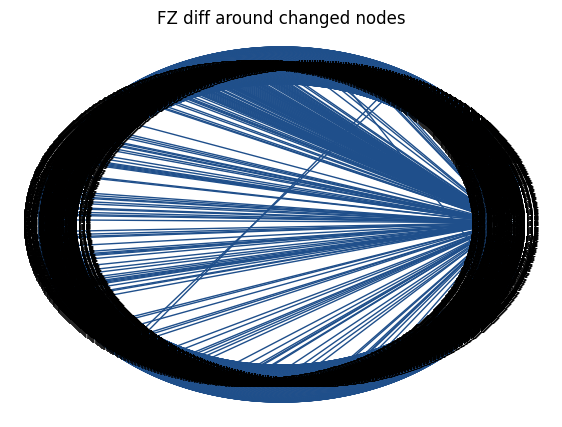

In [51]:
rows = load_fz_arff("dataset/fz.arff")
g = build_fz_graph(rows)
print("Before:", graph_summary(g))

g_before = g.copy()

agent = ChaosAgent(model_name=None, seed=3)
ops = agent.plan(g, max_ops=3)
results = agent.apply(g, ops)

print("Ops:", ops)
print("Results:", results)
print("After:", graph_summary(g))

sub_before, sub_after = subgraph_around_changes(g_before, g, radius=1)
g_union = nx.compose(sub_before, sub_after)
pos = nx.circular_layout(g_union)
graph_diff_view(sub_before, sub_after, "FZ diff around changed nodes", pos=pos)

save_graph(g, "fz_corrupted_graph.json")
save_corruption_log(ops, results, "fz_corruption_log.json")
